## Goal
Use embeddings + clustering (unsupervised ML) to group related procedural paragraphs into logical "classes" or modules.

This shows the **unsupervised learning** component of the project.

In [16]:
# Cell 1: Setup
import sys
sys.path.append('..')
from src.cobol_parser import parse_cobol
from src.models import cluster_procedural_patterns, CodeEmbedder
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np

# Parse example
parsed = parse_cobol('../data/simple_account.cbl')

# Extract paragraph texts and names safely
paragraph_texts = [body.strip() for name, body in parsed['raw_paragraphs'] if body.strip()]
method_names = [name.strip() for name, body in parsed['raw_paragraphs'] if body.strip()]

print(f"Extracted {len(paragraph_texts)} procedural paragraphs for visualization:")
for i, (name, text) in enumerate(zip(method_names, paragraph_texts)):
    print(f"{i}: {name} → {text[:80]}...")

Extracted 14 procedural paragraphs for visualization:
0: ACCOUNT → DATA...
1: DIVISION → WORKING-STORAGE...
2: SECTION → 01...
3: ACCOUNT → 05 ACCOUNT-NUMBER     PIC 9(10).
   05 ACCOUNT-BALANCE    PIC S9(10)...
4: V99 → 05 ACCOUNT-OWNER      PIC X(50).
   05 TRANSACTION-AMOUNT PIC S9(8)...
5: V99 → PROCEDURE...
6: MAIN → PERFORM...
7: PROCESS → PERFORM...
8: PROCESS → PERFORM...
9: PROCESS → ADD TRANSACTION-AMOUNT TO...
10: ACCOUNT → DISPLAY "DEPOSIT PROCESSED FOR ACCOUNT "...
11: PROCESS → SUBTRACT TRANSACTION-AMOUNT FROM...
12: ACCOUNT → DISPLAY "WITHDRAWAL PROCESSED FOR ACCOUNT "...
13: GENERATE → DISPLAY "ACCOUNT BALANCE REPORT: "...


In [17]:
# Cell 2: Clustering
clusters = cluster_procedural_patterns(paragraph_texts, n_clusters=2)
print("Cluster assignments:", clusters)

# Simple visualization of clusters
for i, (cluster_id, text) in enumerate(zip(clusters, paragraph_texts)):
    print(f"Cluster {cluster_id}: {parsed['potential_methods'][i]}")

Cluster assignments: [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Cluster 1: DIVISION
Cluster 1: PROGRAM
Cluster 1: ACCOUNT
Cluster 1: DIVISION
Cluster 1: SECTION
Cluster 0: ACCOUNT
Cluster 1: V99
Cluster 1: V99
Cluster 1: DIVISION
Cluster 1: MAIN
Cluster 1: PROCESS
Cluster 1: PROCESS
Cluster 1: GENERATE
Cluster 1: RUN


=== t-SNE Visualization of COBOL Paragraph Embeddings ===
Chapter 3: Unsupervised transformations + manifold learning...
Extracted 14 procedural paragraphs


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10833.92it/s]


Cluster labels: [2 2 2 2 2 0 1 1 1 2 2 2 2 2]


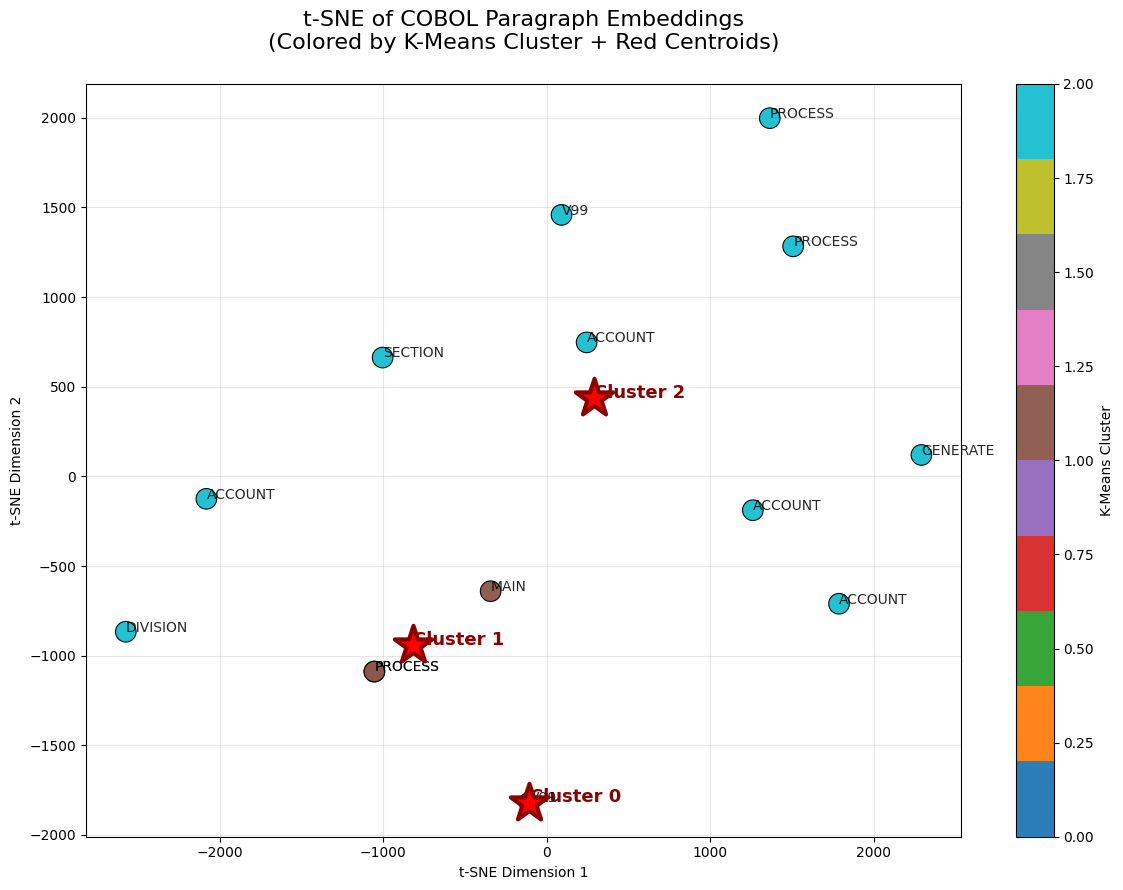

In [24]:
# === Final t-SNE Visualization - Colored Points + Red Star Centroids ===
print("=== t-SNE Visualization of COBOL Paragraph Embeddings ===")
print("Chapter 3: Unsupervised transformations + manifold learning...")

# Parse COBOL
parsed = parse_cobol('../data/simple_account.cbl')

# Extract texts and names safely
paragraph_texts = [body.strip() for name, body in parsed['raw_paragraphs'] if body.strip()]
method_names = [name.strip() for name, body in parsed['raw_paragraphs'] if body.strip()]

print(f"Extracted {len(paragraph_texts)} procedural paragraphs")

# Embeddings
embedder = CodeEmbedder()
embeddings = embedder.embed_texts(paragraph_texts)

# Scale before t-SNE (recommended in textbook)
from sklearn.preprocessing import StandardScaler
embeddings_scaled = StandardScaler().fit_transform(embeddings)

# t-SNE
from sklearn.manifold import TSNE
n_samples = len(paragraph_texts)
perplexity = min(8, max(5, n_samples - 1))

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    early_exaggeration=12,
    learning_rate=200,
    max_iter=2000,
    init='pca'
)

embeddings_2d = tsne.fit_transform(embeddings_scaled)

# Clustering for coloring
clusters = cluster_procedural_patterns(paragraph_texts, n_clusters=3)
clusters = np.array(clusters)

print(f"Cluster labels: {clusters}")

# === Plot with BOTH colors and red stars ===
plt.figure(figsize=(12, 9))

# 1. Colored scatter points
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=clusters, cmap='tab10', s=220,
                      edgecolors='k', linewidth=0.8, alpha=0.95, zorder=3)

plt.colorbar(scatter, label='K-Means Cluster')

# 2. Red star centroids (very prominent)
unique_clusters = np.unique(clusters)
for c in unique_clusters:
    mask = clusters == c
    if np.sum(mask) > 0:
        centroid = embeddings_2d[mask].mean(axis=0)
        plt.scatter(centroid[0], centroid[1],
                    marker='*', s=800, c='red',
                    edgecolors='darkred', linewidth=3, zorder=10)
        plt.text(centroid[0] + 0.5, centroid[1] + 0.5, f'Cluster {c}',
                 fontsize=13, fontweight='bold', color='darkred',
                 bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=3))

# 3. Paragraph name annotations
for i, name in enumerate(method_names):
    short_name = name if len(name) <= 18 else name[:15] + '...'
    plt.annotate(short_name,
                 (embeddings_2d[i, 0] + 0.4, embeddings_2d[i, 1] + 0.4),
                 fontsize=10, alpha=0.85, color='black', ha='left')

plt.title('t-SNE of COBOL Paragraph Embeddings\n'
          '(Colored by K-Means Cluster + Red Centroids)',
          fontsize=16, pad=25)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()